In [1]:
import pandas as pd
races = pd.read_csv("races.csv", parse_dates=["event_date"])
metrics = pd.read_csv("daily_metrics.csv", parse_dates=["date"])
# Filter to Blake Bullard
races = races[races["athlete_id"] == 13].copy()
metrics = metrics[metrics["athlete_id"] == 13].copy()
# Only finished races
races = races[races["finish_status"] == "FINISH"].copy()
lookback_days = 14  # Try 7, 14, 21, 28 later
rows = []
for _, race in races.iterrows():
    window_start = race["event_date"] - pd.Timedelta(days=lookback_days)
    window_end = race["event_date"] - pd.Timedelta(days=1)  # Don't include race day
    # Filter metrics for this athlete in this window
    mask = (
        (metrics["athlete_id"] == race["athlete_id"])
        & (metrics["date"] >= window_start)
        & (metrics["date"] <= window_end)
    )
    window = metrics[mask]
    if len(window) < 3:  # Skip if too little data
        continue
    rows.append({
        "athlete_id": race["athlete_id"],
        "event_date": race["event_date"],
        "event_name": race["event_name"],
        "race_category": race["race_category"],
        "finish_position": race["finish_position"],
        "finish_pct": race["finish_pct"],
        "field_size": race["field_size"],
        # Pre-race averages
        "avg_hrv": window["hrv"].mean(),
        "avg_rhr": window["rhr"].mean(),
        "avg_sleep": window["sleep_hours"].mean(),
        "avg_daily_tss": window["total_tss"].mean(),
        "avg_daily_hours": window["total_duration_hrs"].mean(),
        "avg_num_workouts": window["num_workouts"].mean(),
        "days_with_data": len(window),
    })
analysis_df = pd.DataFrame(rows)

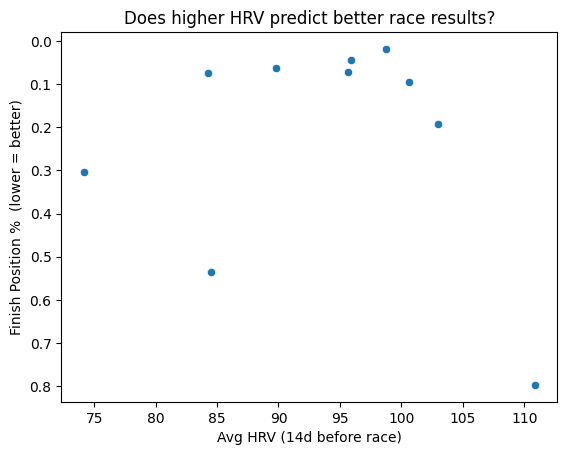

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# Scatter: HRV vs finish percentage
sns.scatterplot(data=analysis_df, x="avg_hrv", y="finish_pct")
plt.xlabel("Avg HRV (14d before race)")
plt.ylabel("Finish Position %  (lower = better)")
plt.title("Does higher HRV predict better race results?")
plt.gca().invert_yaxis()  # Lower % = better
plt.show()

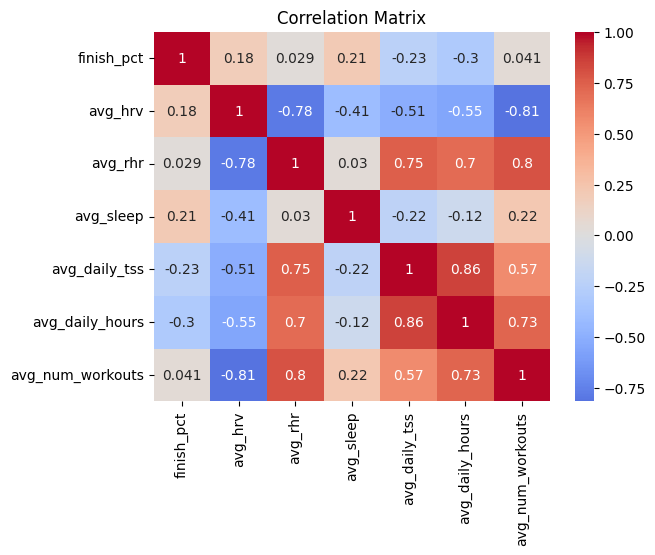

In [4]:
cols = ["finish_pct", "avg_hrv", "avg_rhr", "avg_sleep", "avg_daily_tss", "avg_daily_hours", "avg_num_workouts"]
sns.heatmap(analysis_df[cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()